# Statics Problems and Solutions

## Code Setup

The necessary packages are imported below. For this project, we will be using the numpy and pint packages. The pint package helps with unit handling and conversions.

In [ ]:
#!pip install pint

import numpy as np
from pint import UnitRegistry

ureg = UnitRegistry()
print(ureg)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.0/302.0 kB 17.0 MB/s eta 0:00:00


### **Problem 2**###

The picture of the problem needs to be coded into Python so that it is visible to viewers in the coding space. We will use the `import` function to import Problem 2. `.display` will show the image on the coding space.

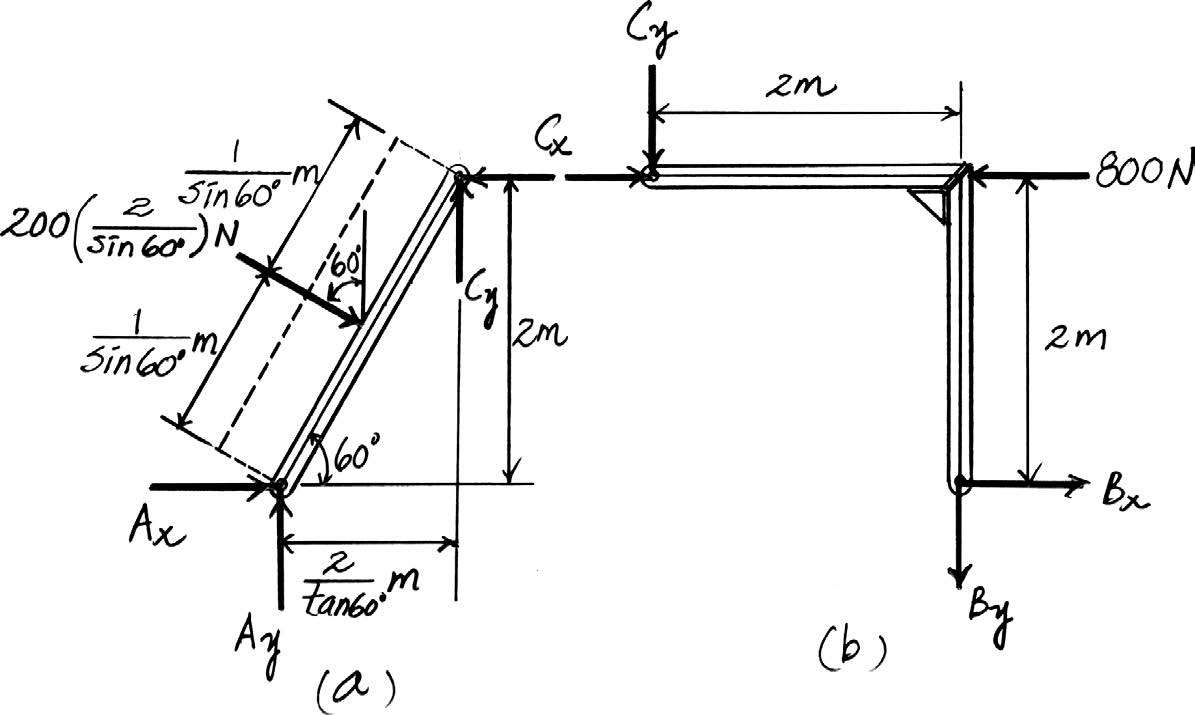

In [ ]:
from PIL import Image
from IPython.display import display
prob2 = Image.open('FBD Problem #2.png')
display(prob2)

Problem #2: Determine the resultant force at pins A, B, and C on the three-member frame.

Shown above is a free-body diagram for the problem.

#### Step 1: Set Up Problem ####

We start off Problem #2 by defining the known variables and quantities that were given to us in the problem.

In [ ]:
#The code below identifies the known values from the given statics problem and assigns units.
F_1 = 800 * ureg.newton
F_2 = 200 * (ureg.newton/ureg.meter)
SegB = 2 * ureg.meter
SegC = 2 * ureg.meter
Theta_A = (60 * ureg.degree)
Theta_A = Theta_A.to(ureg.radian)

`ureg` function is the **Unit Registry** which is under the `pint` package. It can call units in the registry when dealing with quantities. For example, `ureg.newton` calls the Newton (N) unit for the number 800.

It is not valid syntax to just type F_1 = 800 N because "N" is not a built-in unit in Python (you need the pint package). Using the Unit Registry ensures proper unit handling, easy conversions, and accurate unit calculations. Similar to the real world, you must put the respective units to numbers while coding to prevent any mix-ups and/or errors.

####Step 2: Write Function####

Functions in Python require `def` which defines the function followed by `return` which returns the values of the unknowns. We will set up equilibrium in the x and y direction for forces A, B, and C using trig functions (`sin()`, `cos()`, and `tan()`). The magnitudes of the resultant forces at the three points are determined using the **Pythagorean Theorem**. The calculated magnitudes will be returned.

In [ ]:
# The code below creates a new function where the unknowns are found
def calc_Force(F_1, F_2, SegB, Theta_A):
    #This equation solves for Force C in the x-direction
    C_x = ((np.tan(Theta_A)*(F_2*((SegB/(np.sin(Theta_A)))*(SegB/(2*np.sin(Theta_A)))))) + (F_1*SegB))/(SegB+(SegB * np.tan(Theta_A)))
    #This equation solves for Force C in the y-direction
    C_y = (((SegC*C_x)-(F_1*SegB))/SegC)

    #This equation solves for Force A in the x-direction
    A_x = (-F_2*(SegB/np.sin(Theta_A))*np.sin(Theta_A)) + C_x
    #This equation solves for Force A in the y-direction
    A_y = (-C_y) + (F_2*(SegB/np.sin(Theta_A))*np.cos(Theta_A))

    #This code below solves for force B using the C forces solved for previously
    B_x = F_1 - C_x
    B_y = (-C_y)

    #The magnitude of A, B, and C forces are solved below
    F_c = ((C_x**2)+(C_y**2))**(1/2)
    F_A = ((A_x**2)+(A_y**2))**(1/2)
    F_b = ((B_x**2)+(B_y**2))**(1/2)

    return F_c, F_A, F_b


####Step 3: Print####

The `return` code does not print out the answers so we will use `print` to do just that. The force magnitudes will be printed out in Newtons (N) and force pounds (lbf). The conversion is to show the client Python's ability to easily convert between units.

In [ ]:
#Assigns the forces to the function and calling the function
F_c, F_A, F_b = calc_Force(F_1, F_2, SegB, Theta_A)

#The answers are printed out
print('The force magnitude of A is {0:.2f}.'.format(F_A))
print('The force magnitude of B is {0:.2f}.'.format(F_b))
print('The force magnitude of C is {0:.2f}.'.format(F_c))

#The answers from above are converted to force pounds to show the python code is capable of unit conversion
F_A = F_A.to(ureg.lbf)
F_b = F_b.to(ureg.lbf)
F_c = F_c.to(ureg.lbf)

#The converted answers are printed out
print('The force magnitude of A is {0:.2f}.'.format(F_A))
print('The force magnitude of B is {0:.2f}.'.format(F_b))
print('The force magnitude of C is {0:.2f}.'.format(F_c))


The force magnitude of A is 572.41 newton.
The force magnitude of B is 478.17 newton.
The force magnitude of C is 572.41 newton.
The force magnitude of A is 128.68 force_pound.
The force magnitude of B is 107.50 force_pound.
The force magnitude of C is 128.68 force_pound.


### **Problem 3**

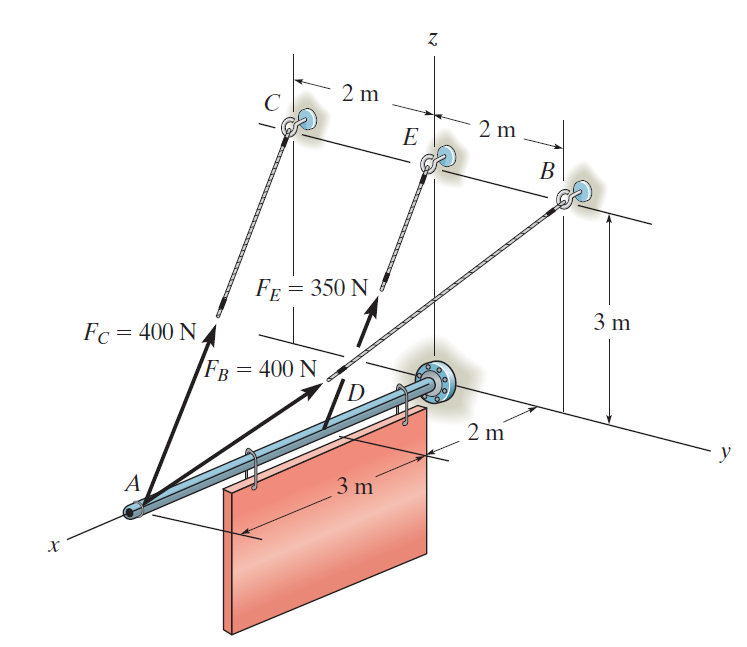

In [ ]:
from PIL import Image
from IPython.display import display
prob3 = Image.open('FBD Problem #3.PNG')
display(prob3)

Problem #3: Determine the magnitude and coordinate direction angles of the resultant force of the two forces acting on the sign at point A.

####Step 1: Set Up Problem####

In [ ]:
#The code below identifies the known values from the given statics problem #3 and assigns units.
#the values below are the position where each force is applied
r_c_x = (-5)*ureg.meter
r_c_y = (-2) *ureg.meter
r_c_z = 3*ureg.meter
r_b_x = (-5)*ureg.meter
r_b_y = (2) *ureg.meter
r_b_z = 3*ureg.meter

#This shows the magnitude of each given force
F_c_mag = 400*ureg.newton
F_b_mag = 400*ureg.newton

####Step 2: Write Function####

The forces need to be in vector format in order to calculate the direction angles. Since we are in 3D space, we will **vectorize** forces C and B by calculating their x, y, and z components using the respective **unit vectors**. For instance, `F_c_x` is the x-component of force C. We will multiply the force magnitude by the corresponding component of the unit vector. We can add `F_c_x` and `F_b_x` to get the x component of the resultant force. We need to do the same for y and z.

If we calculate the magnitude of the resulant force using Pythagorean Theorem, we can find the direction angles using the inverse trig functions `arccos()`. This will be done by taking the inverse cosine of a component of the resultant force divided by the magnitude of the resultant force.

In [ ]:
#The function to calculate the force and its angles is defined below
def calc_F_r(r_c_x, r_c_y, r_c_z, r_b_x, r_b_y, r_b_z, F_c_mag, F_b_mag):
    #The magnitude of C is calculated below
    r_c = ((r_c_x**2)+(r_c_y**2)+(r_c_z**2))**(1/2)

    #The force C is vectorized below
    F_c_x = F_c_mag*(r_c_x/r_c)
    F_c_y = F_c_mag*(r_c_y/r_c)
    F_c_z = F_c_mag*(r_c_z/r_c)

    #The force B is vectorized below
    F_b_x = F_b_mag*(r_b_x/r_c)
    F_b_y = F_b_mag*(r_b_y/r_c)
    F_b_z = F_b_mag*(r_b_z/r_c)

    #The resultant force is calculated below
    F_r_x = F_c_x + F_b_x
    F_r_y = F_c_y + F_b_y
    F_r_z = F_c_z + F_b_z

    #The magnitude of the force is calculated below
    F_r = ((F_r_x**2)+(F_r_y**2)+(F_r_z**2))**(1/2)

    #The force angles are calculated below
    alpha = np.arccos(F_r_x/F_r)
    alpha = alpha.to(ureg.degree)

    beta = beta = np.arccos(F_r_y/F_r)
    beta = beta.to(ureg.degree)

    gamma = gamma = np.arccos(F_r_z/F_r)
    gamma = gamma.to(ureg.degree)
    return F_r, alpha, beta, gamma

####Step 3: Print####

The angles and resutant froce are printed.

In [ ]:
#The function that has been defined is called below and assigned the values we are solving for
F_r, alpha, beta, gamma = calc_F_r(r_c_x, r_c_y, r_c_z, r_b_x, r_b_y, r_b_z, F_c_mag, F_b_mag)
print('The angle alpha is {0:.2f}.'.format(alpha))
print('The angle beta is {0:.2f}.'.format(beta))
print('The angle gamma is {0:.2f}.'.format(gamma))
print('The force magnitude is {0:.2f}.'.format(F_r))

The angle alpha is 149.04 degree.
The angle beta is 90.00 degree.
The angle gamma is 59.04 degree.
The force magnitude is 756.72 newton.


### **Problem 4**

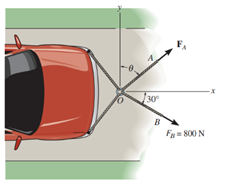

In [ ]:
from PIL import Image
from IPython.display import display
prob4 = Image.open('FBD Problem #4.png')
display(prob4)

Problem #4: Determine the magnitude and direction of F_a so that the resultant force is directed along the postive x-axis and has a magnitude of 1250 N.

####Step 1: Set Up Problem####

In [ ]:
#The code below identifies the knowns(arguments) and assigns the labels
F_b = 800*ureg.newton
theta_b = 330*ureg.degree
F_r = 1250*ureg.newton
theta_r = 0 *ureg.degree

####Step 2: Write Function####

Before we begin to solve the statics problem, we must convert `theta_b` and `theta_r` to radians because trig functions in `numpy` work with radians.
We will calculate the magnitude and direction angle of Force A using basic principles of vector addition, trig, and unit conversions in Python.

In [ ]:
#The function to calculate force A is defined below
def calc_force_A(F_b, theta_b, F_r, theta_r):
    #The angles are converted to radians to accomodate for pint library
    theta_b = theta_b.to(ureg.radian)
    theta_r = theta_r.to(ureg.radian)
    degree_y = 90 * ureg.degree

    # The resultant force is split up into vector
    F_r_x = F_r * np.cos(theta_r)
    F_r_y = F_r *np.sin(theta_r)

    #Force A is calculated below in x and y direction
    F_A_x = F_r_x - (F_b*np.cos(theta_b))
    F_A_y = F_r_y + (F_b*np.sin(theta_b))

    #Magnitude of Force A is calculated
    F_a = ((F_A_x**2)+(F_A_y**2))**(1/2)

    #The angle which the Force A acts is calculated below
    theta_a = np.arccos(F_A_x/F_a)
    theta_a = theta_a.to(ureg.degree)
    #The angle was originally treated as measured from x-axis but the answer is measured from y
    theta_a = degree_y - theta_a
    return F_a, theta_a
    #Function is called below and assigned to the answers
F_a, theta_a = calc_force_A(F_b, theta_b, F_r, theta_r)


####Step 3: Print####

Print the angle and force magnitude.

In [ ]:
#The answers are formatted and printed
print('The angle theta with respect to y axis is {0:.2f}.'.format(theta_a))
print('The force magnitude is {0:.2f}.'.format(F_a))

The angle theta with respect to y axis is 54.33 degree.
The force magnitude is 685.89 newton.
